# SAHI with GroundingDINO for Zero-Shot Sliced Inference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/obss/sahi/blob/main/demo/inference_for_groundingdino.ipynb)

## 0. Preparation

- Install latest version of SAHI and HuggingFace transformers:

In [ ]:
!pip install -U sahi
!pip install transformers timm

In [ ]:
import os

os.getcwd()

- Import required modules:

In [1]:
# import required functions, classes
import os

from IPython.display import Image

from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction, predict
from sahi.utils.cv import read_image
from sahi.utils.file import download_from_url

You can see zero-shot object detection models available at [HF model hub](https://huggingface.co/models?pipeline_tag=zero-shot-object-detection&sort=downloads). We use the smallest variant of GroundingDINO model for this demo.

In [2]:
# Select a model to use, we use a GroundingDINO model.
model_path = "IDEA-Research/grounding-dino-tiny"  # larger model: IDEA-Research/grounding-dino-base
text_labels = ["car", "truck", "person"]

# download test images into demo_data folder
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/small-vehicles1.jpeg",
    "demo_data/small-vehicles1.jpeg",
)
download_from_url(
    "https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/terrain2.png", "demo_data/terrain2.png"
)

## 1. Standard Inference with HuggingFace GroundingDINO Model

- Instantiate a detection model by defining model weight path, config path and other parameters:

In [3]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="huggingface",
    model_path=model_path,
    confidence_threshold=0.5,
    text_threshold=0.25,
    text_labels=text_labels,
    image_size=640,
    device="cpu",  # or 'cuda'
)

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


- Perform prediction by feeding the `get_prediction` function with an image path and a DetectionModel instance:

In [4]:
result = get_prediction("demo_data/small-vehicles1.jpeg", detection_model)

- Or perform prediction by feeding the `get_prediction` function with a numpy image and a DetectionModel instance:

In [5]:
result = get_prediction(read_image("demo_data/small-vehicles1.jpeg"), detection_model)

- Visualize predicted bounding boxes over the original image:

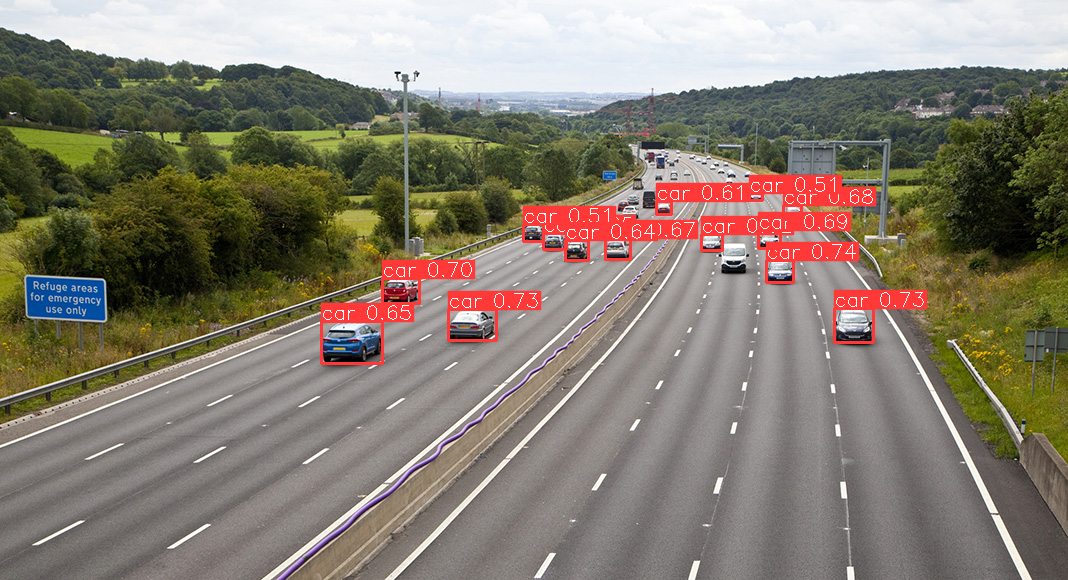

In [6]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

## 2. Sliced Inference with HuggingFace GroundingDINO Model

- To perform sliced prediction we need to specify slice parameters. In this example we will perform prediction over slices of 512x512 with an overlap ratio of 0.2:

In [7]:
result = get_sliced_prediction(
    "demo_data/small-vehicles1.jpeg",
    detection_model,
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

Performing prediction on 15 slices.


- Visualize predicted bounding boxes over the original image:

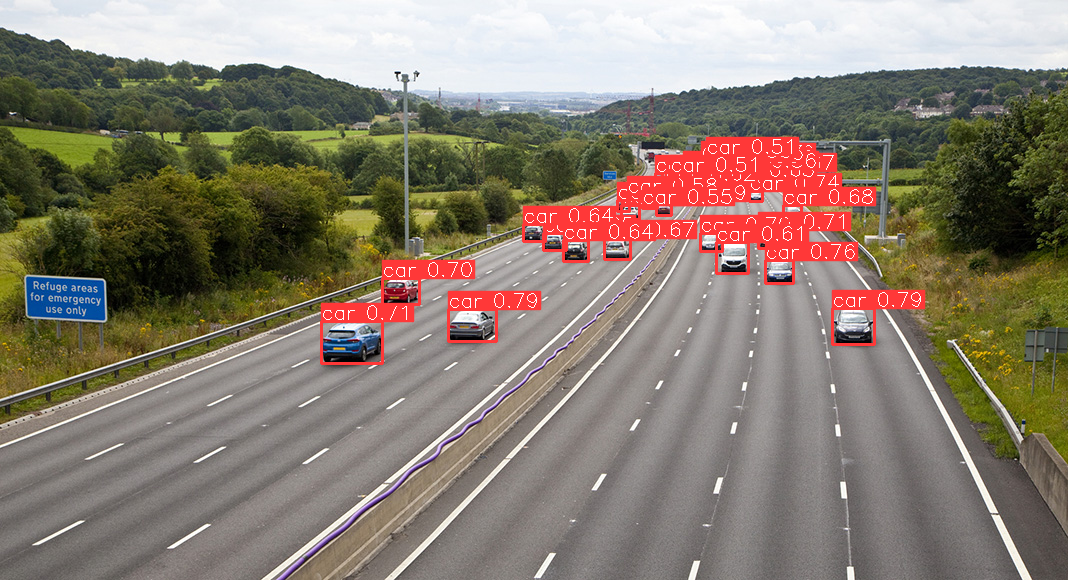

In [8]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

## 3. Prediction Result

- Predictions are returned as [sahi.prediction.PredictionResult](sahi/prediction.py), you can access the object prediction list as:

In [9]:
object_prediction_list = result.object_prediction_list

In [10]:
object_prediction_list[0]

ObjectPrediction<
    bbox: BoundingBox: <(np.float64(832.5057983398438), np.float64(308.19989013671875), np.float64(874.0925712585449), np.float64(344.231689453125)), w: 41.58677291870117, h: 36.03179931640625>,
    mask: None,
    score: PredictionScore: <value: 0.7869185209274292>,
    category: Category: <id: 0, name: car>>

In [11]:
result.to_coco_annotations()[:3]

[{'image_id': None,
  'bbox': [832.5057983398438,
   308.19989013671875,
   41.58677291870117,
   36.03179931640625],
  'score': 0.7869185209274292,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1498},
 {'image_id': None,
  'bbox': [448.2284851074219,
   309.17767333984375,
   47.894012451171875,
   32.02731704711914],
  'score': 0.7855542898178101,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1533},
 {'image_id': None,
  'bbox': [765.5368804931641,
   260.6347846984863,
   28.252609252929688,
   23.18532943725586],
  'score': 0.7592191100120544,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 655}]

- ObjectPrediction's can be converted to [COCO prediction](https://github.com/i008/COCO-dataset-explorer) format:

In [12]:
result.to_coco_predictions(image_id=1)[:3]

[{'image_id': 1,
  'bbox': [832.5057983398438,
   308.19989013671875,
   41.58677291870117,
   36.03179931640625],
  'score': 0.7869185209274292,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1498},
 {'image_id': 1,
  'bbox': [448.2284851074219,
   309.17767333984375,
   47.894012451171875,
   32.02731704711914],
  'score': 0.7855542898178101,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1533},
 {'image_id': 1,
  'bbox': [765.5368804931641,
   260.6347846984863,
   28.252609252929688,
   23.18532943725586],
  'score': 0.7592191100120544,
  'category_id': 0,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 655}]

- ObjectPrediction's can be converted to [fiftyone](https://github.com/voxel51/fiftyone) detection format:

In [14]:
# !pip install fiftyone
result.to_fiftyone_detections()[:3]

[<Detection: {
     'id': '6a0d9d5782520ef443adbd64',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.779499811179629,
         0.5313791209253772,
         0.03893892595384005,
         0.06212379192483836,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.7869185209274292,
     'index': None,
 }>,
 <Detection: {
     'id': '6a0d9d5782520ef443adbd65',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.4196895927972115,
         0.5330649540342134,
         0.04484458094679015,
         0.055219512150205416,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.7855542898178101,
     'index': None,
 }>,
 <Detection: {
     'id': '6a0d9d5782520ef443adbd66',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.7167948319224383,
         0.4493703184456661,
         0.0264537539821439,
         0.03997470592630321,
   

- ObjectPrediction's can be converted to [imantics](https://github.com/jsbroks/imantics) annotation format:

In [15]:
# !pip install -U imantics
result.to_imantics_annotations()[:3]

## 4. Batch Prediction

- Set model and directory parameters:

In [16]:
model_type = "huggingface"
model_device = "cpu"  # or 'cuda:0'
model_confidence_threshold = 0.5
text_threshold = 0.25

slice_height = 512
slice_width = 512
overlap_height_ratio = 0.2
overlap_width_ratio = 0.2

source_image_dir = "demo_data/"

- Perform sliced inference on given folder:

In [17]:
predict(
    model_type=model_type,
    model_path=model_path,
    model_device=model_device,
    model_confidence_threshold=model_confidence_threshold,
    source=source_image_dir,
    slice_height=slice_height,
    slice_width=slice_width,
    overlap_height_ratio=overlap_height_ratio,
    overlap_width_ratio=overlap_width_ratio,
    text_labels=text_labels,
    text_threshold=text_threshold,
)

There are 4 listed files in folder: demo_data/


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Performing inference on images:   0%|          | 0/4 [00:00<?, ?it/s]

Performing prediction on 15 slices.


Performing inference on images:  25%|██▌       | 1/4 [01:52<05:37, 112.46s/it]

...

Prediction time is: 51225.82 ms
Performing prediction on 6 slices.


Performing inference on images:  75%|███████▌  | 3/4 [03:32<01:03, 63.63s/it]

Prediction time is: 48238.67 ms
Performing prediction on 6 slices.


Performing inference on images: 100%|██████████| 4/4 [04:20<00:00, 65.24s/it]

Prediction time is: 48789.76 ms
Prediction results are successfully exported to runs\predict\exp
